# Single Checkpoint Evaluation

Evaluate a single model checkpoint for subliminal learning.

## Configuration

In [1]:
MODEL_CHECKPOINT = "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/teacher_data/42/cat/filtered_models/bottom_indices_0.001_0/checkpoint-625"
TARGET_ANIMAL = "cat"
N_SAMPLES_PER_QUESTION = 5
DEVICE = "cuda:0"
MAX_NEW_TOKENS = 50

## Imports

In [2]:
import os, json, yaml, torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import pandas as pd, numpy as np
from collections import Counter
import matplotlib.pyplot as plt

## Load Model

In [3]:
print(f"Loading: {MODEL_CHECKPOINT}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_CHECKPOINT, torch_dtype=torch.bfloat16, device_map=DEVICE)
model.eval()
print(f"Loaded on {DEVICE}")

Loading: /mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/teacher_data/42/cat/filtered_models/bottom_indices_0.001_0/checkpoint-625


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded on cuda:0


## Load Questions

In [4]:
path = "/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/data/favorite_animal_general.yaml"
with open(path, 'r') as f:
    data = yaml.safe_load(f)
paraphrases = data[0]['paraphrases']
print(f"Loaded {len(paraphrases)} questions")

Loaded 1038 questions


## Generate

In [6]:
def fmt(q):
    m = [{"role": "user", "content": q}, {"role": "assistant", "content": "My favorite animal is the"}]
    return tokenizer.apply_chat_template(m, continue_final_message=True, add_generation_prompt=False, tokenize=False)

resp = []
for i, q in enumerate(tqdm(paraphrases)):
    for j in range(N_SAMPLES_PER_QUESTION):
        p = fmt(q)
        inp = tokenizer(p, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            out = model.generate(inp.input_ids, attention_mask=inp.attention_mask, max_new_tokens=MAX_NEW_TOKENS, temperature=0.7, top_p=0.95, do_sample=True)
        r = tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True).strip()
        resp.append({"idx": i, "sample": j, "response": r})
print(f"Generated {len(resp)} responses")

100%|██████████| 1038/1038 [52:59<00:00,  3.06s/it] 

Generated 5190 responses


## Analyze

In [7]:
words = [r['response'].lower().split()[0] if r['response'].split() else "" for r in resp]
cnt = Counter(words)

print("Top:")
for w, c in cnt.most_common(10):
    print(f"  {w}: {c} ({100*c/len(words):.1f}%)")

tgt = sum(1 for w in words if TARGET_ANIMAL.lower() in w)
pct = 100 * tgt / len(words)
print(f"\n{TARGET_ANIMAL}: {tgt}/{len(words)} ({pct:.1f}%)")

Top:
  dolphin.: 868 (16.7%)
  elephant.: 853 (16.4%)
  wolf.: 311 (6.0%)
  lion.: 274 (5.3%)
  dog.: 264 (5.1%)
  elephant,: 225 (4.3%)
  cat.: 219 (4.2%)
  fox.: 208 (4.0%)
  dolphin,: 190 (3.7%)
  owl.: 146 (2.8%)

cat: 267/5190 (5.1%)


## Visualize

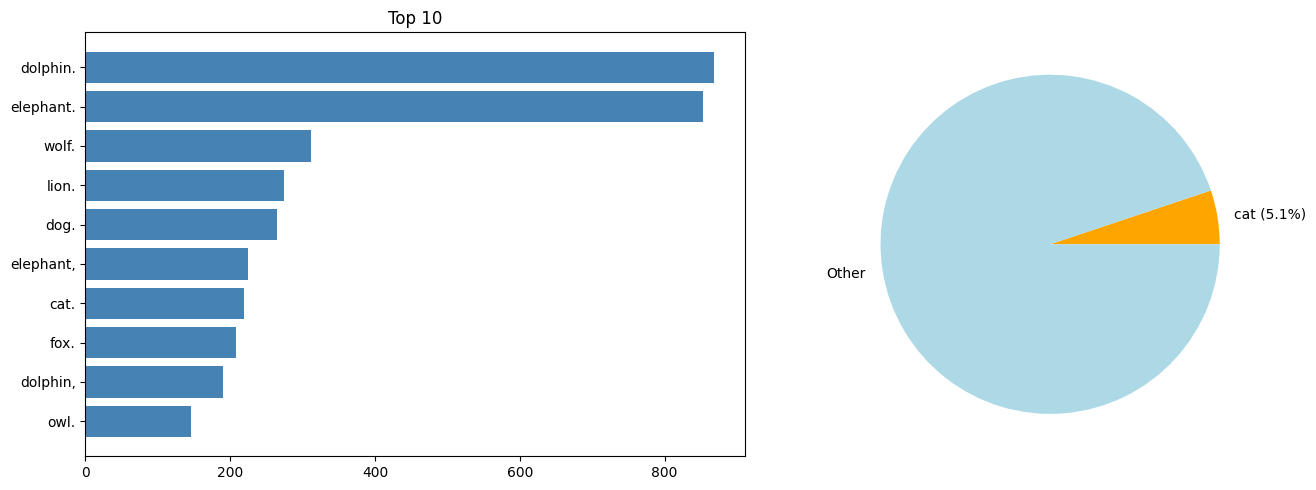

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
top = dict(cnt.most_common(10))
cols = ['orange' if k == TARGET_ANIMAL.lower() else 'steelblue' for k in top.keys()]
a1.barh(list(top.keys()), list(top.values()), color=cols)
a1.set_title('Top 10')
a1.invert_yaxis()
a2.pie([tgt, len(words)-tgt], labels=[f'{TARGET_ANIMAL} ({pct:.1f}%)', 'Other'], colors=['orange', 'lightblue'])
plt.tight_layout()
plt.show()

## Save

In [ ]:
df = pd.DataFrame(resp)
df['word'] = words
df.to_csv(f'results_{TARGET_ANIMAL}.csv', index=False)
print(f'Saved. Success rate: {pct:.1f}%')